# 🌟 XGBoost for Regression – Full Explanation

---

## 🧠 What is XGBoost?

**XGBoost** (e**X**treme **G**radient **Boost**ing) is an optimized implementation of **Gradient Boosting**.

✅ Efficient, scalable, and highly regularized — makes it perfect for **regression tasks**, especially on tabular data.

---

## 🔸 Goal of Regression

Given training data:

* Features: $x_1, x_2, ..., x_n$
* Target: $y \in \mathbb{R}$

We want to learn a model $\hat{y}(x)$ that minimizes the **regression loss**:

```math
L = \sum_{i=1}^n \ell(y_i, \hat{y}_i)
```

Where $\ell$ is typically:

* **Squared error**: $\ell(y_i, \hat{y}_i) = (y_i - \hat{y}_i)^2$
* Or another differentiable loss (Huber, MAE, etc.)

---

## 🔸 Additive Tree Ensemble Model

XGBoost builds an ensemble of decision trees:

```math
\hat{y}_i = \sum_{t=1}^T f_t(x_i), \quad f_t \in \mathcal{F}
```

* $\mathcal{F}$: set of regression trees
* Each $f_t$ is a function (tree) that maps input $x_i$ to a real value

---

## 🔸 Objective Function (with Regularization)

```math
\mathcal{L}^{(t)} = \sum_{i=1}^n \ell(y_i, \hat{y}_i^{(t-1)} + f_t(x_i)) + \Omega(f_t)
```

Where:

* $\hat{y}_i^{(t-1)}$: prediction from previous trees
* $f_t$: the new tree to be added
* $\Omega(f) = \gamma T + \frac{1}{2} \lambda \sum w_j^2$: regularization term

  * $T$: number of leaves
  * $w_j$: leaf weights

---

## 🔸 Taylor Expansion of Loss (2nd Order)

We approximate the loss using a 2nd-order Taylor expansion:

```math
\ell(y_i, \hat{y}_i^{(t-1)} + f_t(x_i)) ≈ \ell(y_i, \hat{y}_i^{(t-1)}) + g_i f_t(x_i) + \frac{1}{2} h_i f_t(x_i)^2
```

Where:

* $g_i = \frac{\partial \ell(y_i, \hat{y}_i)}{\partial \hat{y}_i}$ = first-order gradient
* $h_i = \frac{\partial^2 \ell(y_i, \hat{y}_i)}{\partial \hat{y}_i^2}$ = second-order (Hessian)

Final simplified objective for tree $f_t$:

```math
\mathcal{L}^{(t)} ≈ \sum_{i=1}^n [g_i f_t(x_i) + \frac{1}{2} h_i f_t(x_i)^2] + \Omega(f_t)
```

---

## 🔸 Optimizing a Tree

For a tree with $T$ leaves, define:

* $I_j$: set of data points in leaf $j$
* $G_j = \sum_{i \in I_j} g_i$,  $H_j = \sum_{i \in I_j} h_i$

The **optimal weight** for leaf $j$ is:

```math
w_j^* = -\frac{G_j}{H_j + \lambda}
```

And the **optimal value of the loss** is:

```math
\mathcal{L}^{(t)} = -\frac{1}{2} \sum_{j=1}^T \frac{G_j^2}{H_j + \lambda} + \gamma T
```

---

## 🔸 Split Finding

At each split:

* Try splitting a node into left and right
* Compute loss reduction:

```math
\text{Gain} = \frac{1}{2} \left[ \frac{G_L^2}{H_L + \lambda} + \frac{G_R^2}{H_R + \lambda} - \frac{(G_L + G_R)^2}{H_L + H_R + \lambda} \right] - \gamma
```

Choose the split with the highest **Gain**.

---

## 🔹 Final Prediction

Once the tree is built, predictions are:

```math
\hat{y}(x) = \sum_{t=1}^{T} f_t(x)
```

---

## 🔸 Practical Example (with Squared Loss)

```python
from xgboost import XGBRegressor
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

X, y = make_regression(n_samples=1000, n_features=10, noise=5)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

model = XGBRegressor(objective='reg:squarederror', n_estimators=100)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))
```

---

## 🔸 Supported Regression Objectives in XGBoost

| Objective              | Description                   |
| ---------------------- | ----------------------------- |
| `reg:squarederror`     | Standard squared loss         |
| `reg:logistic`         | Logistic regression           |
| `reg:absoluteerror`    | MAE (robust to outliers)      |
| `reg:pseudohubererror` | Huber loss (smooth MAE)       |
| `count:poisson`        | Count regression (Poisson)    |
| `survival:cox`         | Survival analysis (Cox model) |

---

## 🔹 Regularization Parameters in Regression

| Param       | Description                                      |
| ----------- | ------------------------------------------------ |
| `lambda`    | L2 regularization on leaf weights                |
| `alpha`     | L1 regularization on leaf weights                |
| `gamma`     | Minimum gain required to make a split            |
| `max_depth` | Controls overfitting (leaf-wise trees grow deep) |

---

## 🔸 Summary

| Component          | Role                                       |
| ------------------ | ------------------------------------------ |
| Trees              | Weak learners (regression trees)           |
| Gradient + Hessian | Drive updates for new tree                 |
| Regularization     | Prevent overfitting                        |
| Leaf-wise growth   | Fast and accurate but prone to overfitting |
| Objective Function | Squared loss, MAE, Huber, Poisson, etc.    |

---


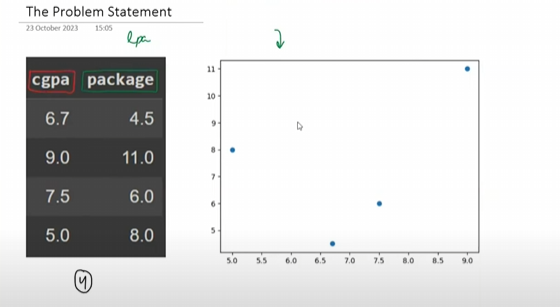

### Pseudo Residuals
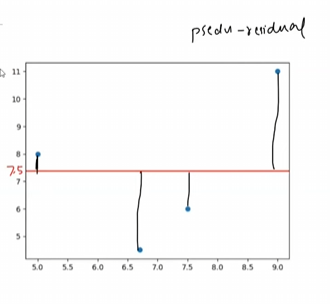

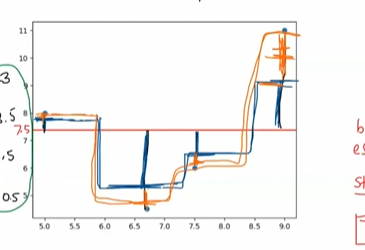

train the model to predict the pseudo residuals etc

The decision trees used in XgBoost are different from vanilla decision trees

We use a different criteria from gini and entropy for construction

The base model used is mean 

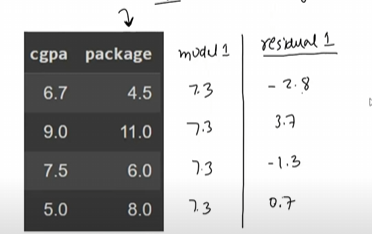

In XGBoost we use similarity score instead of gini and entropy

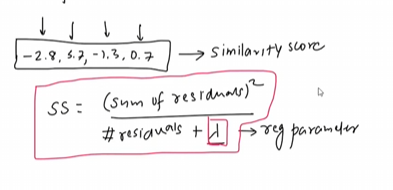

lambda taken 0 for this example
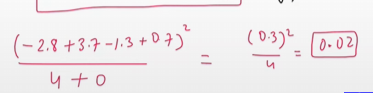

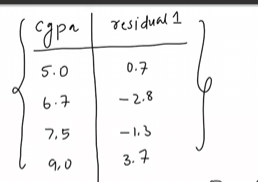

---

# 🌳 XGBoost: Residual-Based Similarity Score Example

---

## 🧠 Background

In regression, XGBoost trains decision trees **sequentially**, where each tree fits the **residuals** (errors) of the previous prediction.

To decide how to split a node, XGBoost calculates the **similarity score (gain)**:

```math
\text{Gain} = \frac{1}{2} \left[ \frac{G_L^2}{H_L + \lambda} + \frac{G_R^2}{H_R + \lambda} - \frac{(G_L + G_R)^2}{H_L + H_R + \lambda} \right] - \gamma
```

Where:

* $G_L, G_R$: sum of gradients on left/right
* $H_L, H_R$: sum of hessians (2nd derivatives)
* $\lambda$: L2 regularization
* $\gamma$: minimum loss reduction to make a split

---

## 🔧 Example Setup

Assume a squared error loss:

```math
\ell(y_i, \hat{y}_i) = \frac{1}{2}(y_i - \hat{y}_i)^2
```

Then:

* Gradient $g_i = \hat{y}_i - y_i$
* Hessian $h_i = 1$

Let’s say we have 4 training points in a node:

| Sample | $y_i$ | $\hat{y}_i$ | Residual $g_i = \hat{y}_i - y_i$ |
| ------ | ----- | ----------- | -------------------------------- |
| 1      | 3     | 2           | -1                               |
| 2      | 2     | 1           | -1                               |
| 3      | 4     | 5           | +1                               |
| 4      | 5     | 6           | +1                               |

Let’s consider a split:

* Left node: samples 1 & 2
* Right node: samples 3 & 4

---

## 🔹 Step 1: Compute G and H

* $G_L = -1 + (-1) = -2$, $H_L = 1 + 1 = 2$
* $G_R = 1 + 1 = 2$, $H_R = 1 + 1 = 2$

Let $\lambda = 1$, $\gamma = 0$

---

## 🔹 Step 2: Plug Into Gain Formula

```math
\text{Gain} = \frac{1}{2} \left[ \frac{(-2)^2}{2 + 1} + \frac{(2)^2}{2 + 1} - \frac{(-2 + 2)^2}{4 + 1} \right]
```

Break it down:

* Left: $\frac{4}{3}$
* Right: $\frac{4}{3}$
* Total: $\frac{0^2}{5} = 0$

So:

```math
\text{Gain} = \frac{1}{2} \left( \frac{4}{3} + \frac{4}{3} - 0 \right) = \frac{1}{2} \cdot \frac{8}{3} = \frac{4}{3} ≈ 1.33
```

✅ **Similarity score (gain) for this split = 1.33**

---

## 🧠 Intuition

* This gain tells you **how much the residual error will reduce** by splitting the node into left and right
* Higher gain ⇒ better split

---

## 🔚 Summary

* XGBoost uses **residual gradients + hessians** to calculate **split quality**
* It does **not** compute similarity as cosine or Euclidean — instead, it uses a **gain based on fitting residuals**
* This makes XGBoost **very efficient and smart** in deciding splits

---



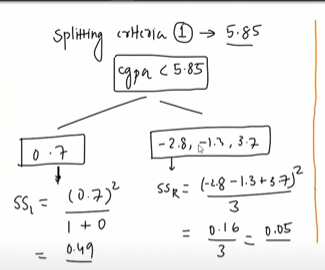 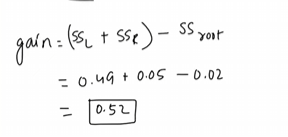

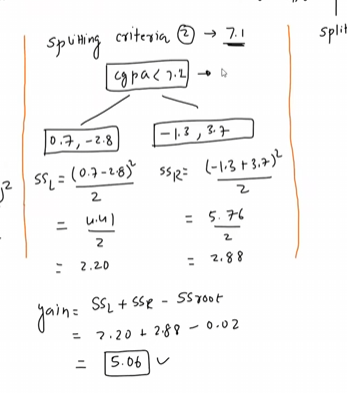

Higher gain

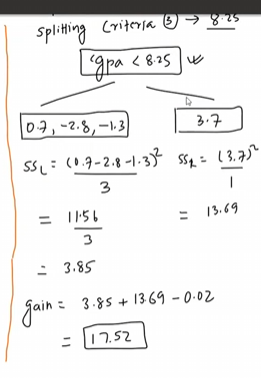

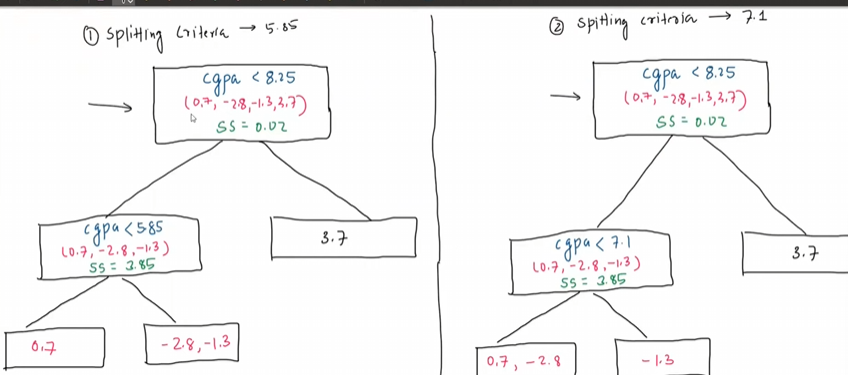

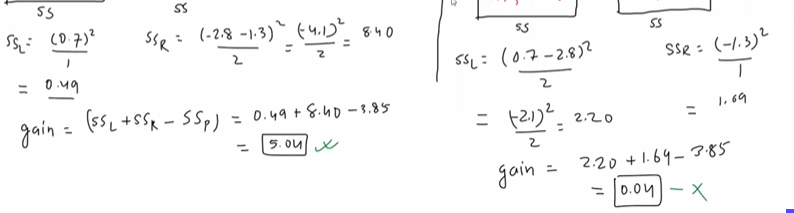

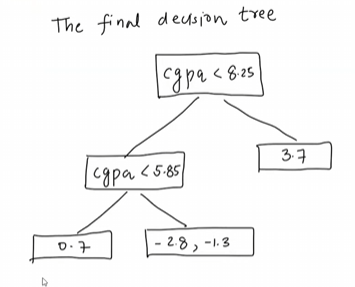

Output of leaf nodes

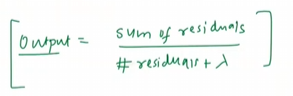

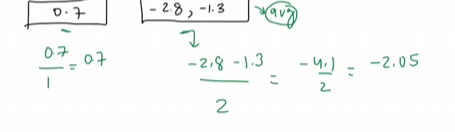

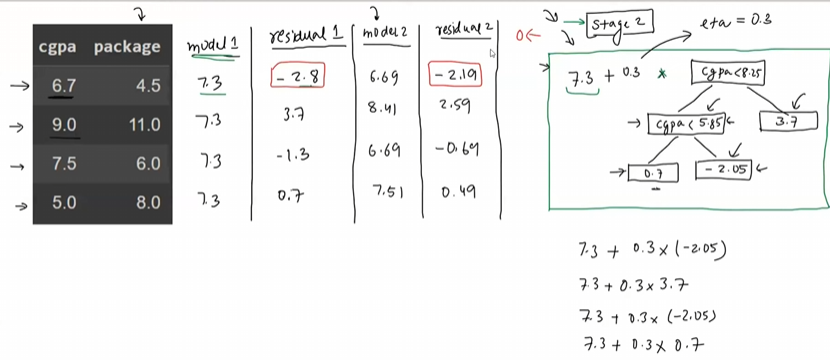

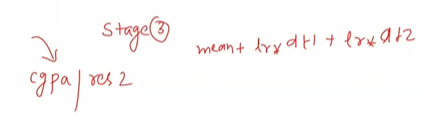

### 🧠 How XGBoost Works with Multiple Features (for Regression or Classification)

---

## 🔹 Big Picture

XGBoost handles **multiple features** just like any decision tree algorithm:

> It tries to **find the best feature + split value** at each node to reduce loss.

Let’s walk through **how it works with multiple features**, step-by-step.

---

## ✅ Example Dataset

Suppose you're predicting house prices:

| Sample | Sqft (F1) | Bedrooms (F2) | Price (Target) |
| ------ | --------- | ------------- | -------------- |
| 1      | 1200      | 3             | 200k           |
| 2      | 1500      | 3             | 250k           |
| 3      | 1000      | 2             | 180k           |
| 4      | 1800      | 4             | 300k           |
| 5      | 900       | 2             | 160k           |

---

## 🔹 Step-by-Step: How XGBoost Uses Multiple Features

### 1️⃣ **Initialize with constant prediction**

XGBoost starts with a constant prediction for all samples:
e.g., the **mean of all target values**

```math
\hat{y}^{(0)} = \frac{1}{n} \sum_{i=1}^{n} y_i
```

---

### 2️⃣ **Compute Residuals (Gradients)**

For each sample $i$:

```math
g_i = \hat{y}_i^{(t-1)} - y_i
h_i = 1  \quad \text{(for squared error)}
```

These represent the "residual" or error the next tree needs to fix.

---

### 3️⃣ **For each feature**, XGBoost tries to find:

* **Best split point**
* **Split gain** (using residuals)

It does this independently for **each feature**.

📌 In our example, it might check:

* For **Sqft (F1)**:
  Try splitting at 1000, 1200, 1500, etc.

* For **Bedrooms (F2)**:
  Try splitting at 2.5, 3.5, etc.

At each candidate split, it evaluates:

```math
\text{Gain} = \frac{1}{2} \left[ \frac{G_L^2}{H_L + \lambda} + \frac{G_R^2}{H_R + \lambda} - \frac{(G_L + G_R)^2}{H_L + H_R + \lambda} \right] - \gamma
```

Whichever **feature + split** gives the **highest gain** → that's the split used.

---

### 4️⃣ **Split the node** using that feature

Let’s say splitting on `Sqft < 1300` gives the best gain. Then the tree node is split:

* Left → samples with `Sqft < 1300`
* Right → `Sqft ≥ 1300`

---

### 5️⃣ **Repeat recursively**

For each child node:

* Compute residuals again
* Try all features again
* Find best split, continue...

This keeps happening until:

* A stopping condition is met (e.g., max depth)
* Or the gain falls below a threshold (`gamma`)

---

## 🧠 Summary

| Step                  | Description                                          |
| --------------------- | ---------------------------------------------------- |
| Compute gradients     | Use residuals from previous predictions              |
| Loop through features | For each feature, evaluate multiple candidate splits |
| Choose best split     | Based on gain from using gradient & hessian          |
| Grow tree             | Split and recurse on children                        |

✅ **XGBoost treats all features equally**, chooses splits **greedily**, and always uses the feature that gives the **highest reduction in loss** at each node.

---

